
# ST2195 – Epsilon-Greedy Multi-Armed Bandit (Python)

**Student Name:** Hasan Rashed Mohamed Almadani  
**Student ID:** stu-00104554    
**Date:** 14 Dec 2025

This notebook runs the Epsilon-Greedy algorithm for a 5-arm bandit with the parameters from the worksheet.

**How to use:** Click **Kernel → Restart & Run All** (or run cells top-to-bottom with Shift+Enter).



## 1) Setup
Import the libraries, set a random seed for reproducibility, and choose a simple plotting style.


In [1]:

# Import required libraries
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility: produce same random numbers every run
SEED = 2025
rng = np.random.default_rng(SEED)

# For nice, readable plots
plt.style.use('seaborn-v0_8')



## 2) Core functions
We define three small helpers:
- `run_bandit(epsilon, n_steps, true_probs, rng)`: runs the epsilon-greedy algorithm and returns estimates, counts, rewards, and chosen arms.
- `cumulative_average(x)`: converts a reward sequence into a running (cumulative) average.
- `plot_cumavg(curves, labels, p_opt, title)`: draws the cumulative average reward curve(s) and a dashed line at the theoretical maximum.


In [2]:
# Epsilon-Greedy runner
def run_bandit(epsilon, n_steps, true_probs, initial_q=0, rng=None):
    """Run epsilon-greedy for given probabilities."""
    true_probs = np.asarray(true_probs, dtype=float)
    K = len(true_probs)
    if rng is None:
        rng = np.random.default_rng()

    Q = np.full(K, initial_q, dtype=float)
    N_arm = np.zeros(K, dtype=int)
    rewards = np.empty(n_steps, dtype=float)
    choices = np.empty(n_steps, dtype=int)
    regrets = np.empty(n_steps, dtype=float)

    p_opt = np.max(true_probs)

    for i in range(n_steps):
        if rng.random() < epsilon:
            arm = rng.integers(0, K)
        else:
            arm = int(np.argmax(Q))

        reward = 1.0 if rng.random() < true_probs[arm] else 0.0
        regret_t = p_opt - true_probs[arm]

        N_arm[arm] += 1
        Q[arm] += (reward - Q[arm]) / N_arm[arm]

        rewards[i] = reward
        choices[i] = arm
        regrets[i] = regret_t

    return Q, N_arm, rewards, choices, regrets

def cumulative_average(x):
    """Return cumulative average of a sequence x."""
    return np.cumsum(x) / (np.arange(len(x)) + 1)

def plot_cumavg(curves, labels, p_opt=None, title='Cumulative Average Reward'):
    """Plot one or more cumulative average reward curves."""
    plt.figure(figsize=(10,6))
    for y, lbl in zip(curves, labels):
        plt.plot(y, label=lbl)
    if p_opt is not None:
        plt.axhline(p_opt, color='black', linestyle='--', linewidth=1.5, label='Theoretical max = {:.2f}'.format(p_opt))
    plt.xlabel('Iteration')
    plt.ylabel('Cumulative average reward')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_regret(curves, labels, title='Cumulative Regret'):
    """Plot one or more cumulative regret curves."""
    plt.figure(figsize=(10,6))
    for y, lbl in zip(curves, labels):
        plt.plot(y, label=lbl)
    plt.xlabel('Iteration')
    plt.ylabel('Cumulative regret')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



## 3) Part A — Single run with ε = 0.10
We use the worksheet's true click probabilities and run **N = 10,000** steps with **ε = 0.10**. Then we plot the cumulative average reward and add a dashed line at the optimal arm's probability (0.50).


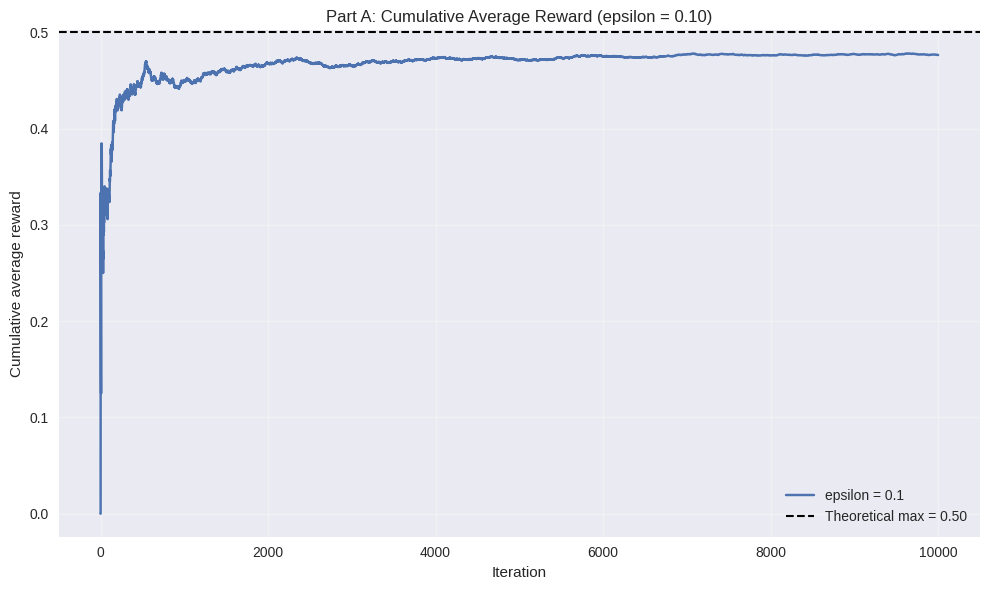

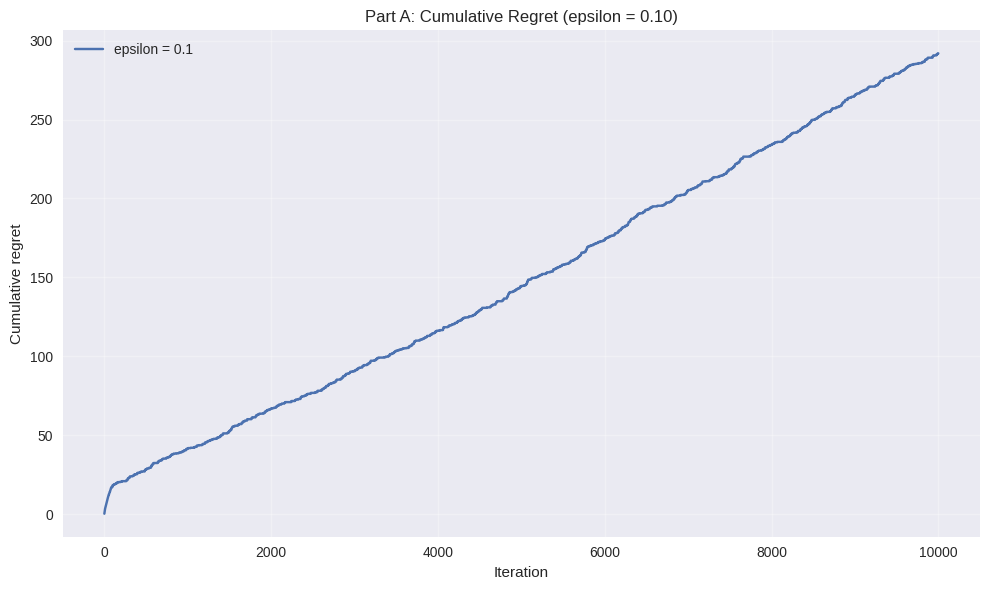

Final estimates Q: [0.103 0.505 0.243 0.053 0.298]
Arm pulls: [ 194 9122  210  226  248]
Optimal arm index: 1 with p= 0.5


In [3]:
# Parameters given from the worksheet
true_probs = np.array([0.10, 0.50, 0.20, 0.05, 0.30])
N = 10_000

# Balanced epsilon
epsilon = 0.10

# Run simulation
Q_A, N_A, rewards_A, choices_A, regrets_A = run_bandit(epsilon, N, true_probs, rng=rng)

cumavg_A = cumulative_average(rewards_A)
cum_regret_A = np.cumsum(regrets_A)

# Plot cumulative average reward
p_opt = float(true_probs.max())
plot_cumavg([cumavg_A], ['epsilon = {}'.format(epsilon)], p_opt=float(true_probs.max()), title='Part A: Cumulative Average Reward (epsilon = 0.10)')

# Plot the cumulative regret
plot_regret([cum_regret_A], ['epsilon = {}'.format(epsilon)], title='Part A: Cumulative Regret (epsilon = 0.10)')

# Helpful printed summary
print("Final estimates Q:", np.round(Q_A, 3))
print("Arm pulls:", N_A)
print("Optimal arm index:", int(np.argmax(true_probs)), "with p=", p_opt)


## 4) Part B — Compare ε = 0.01, 0.10, 0.50
We overlay the cumulative average reward curves for three epsilon values to see the explore–exploit trade-off.

We also print:
- First step where the cumulative average reaches **≥95% of the optimal** (quick convergence proxy)
- Variance of the **last 1000 points** (stability proxy)
- A simple **asymptotic average reward approximation**: \((1-\epsilon)\,p_{\max} + \epsilon\,ar{p}\)


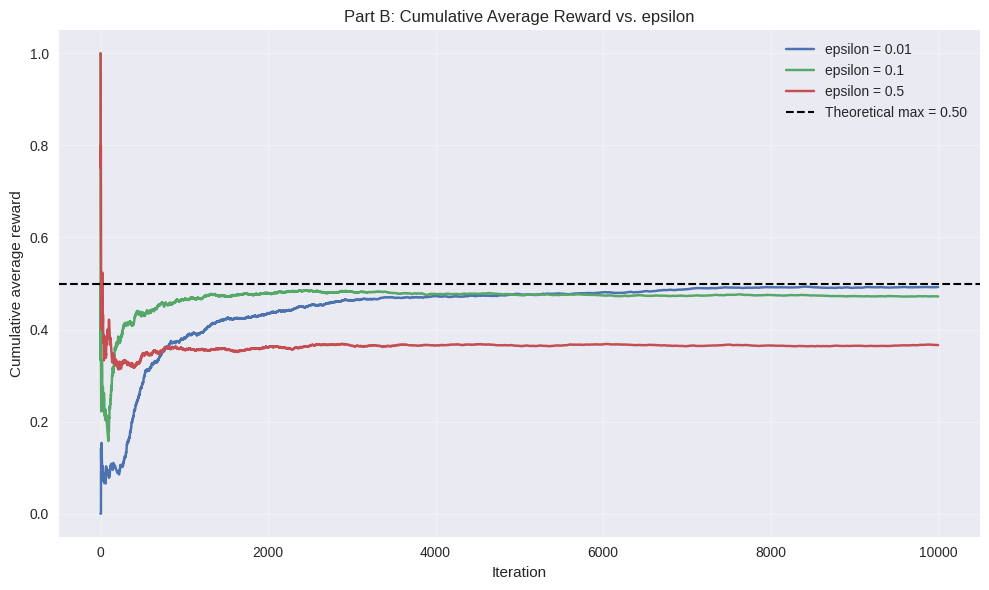

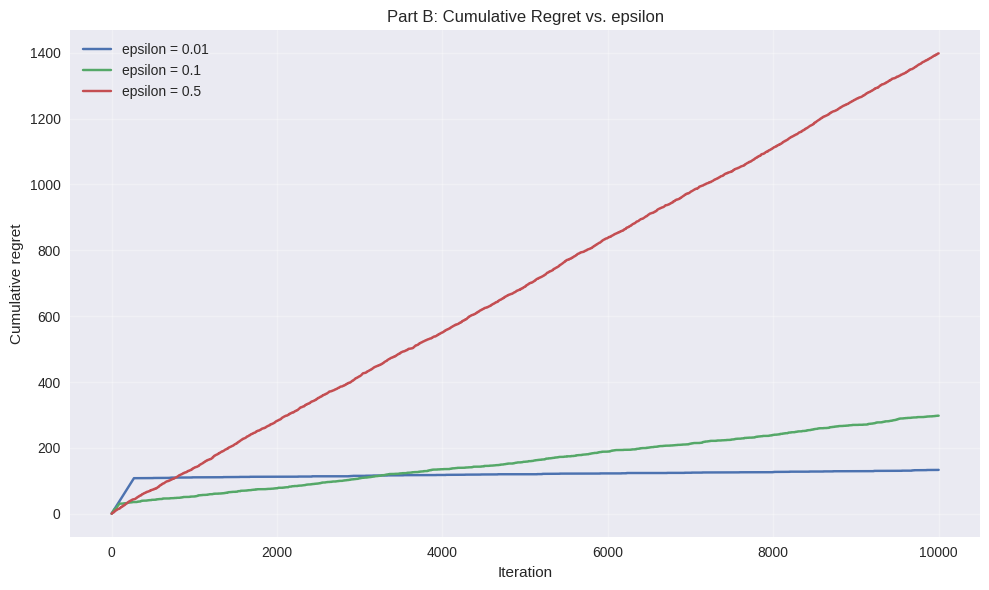

In [4]:
EPS = [0.01, 0.10, 0.50]
results = {}
cumavg_curves = []
cumavg_labels = []
regret_curves = []
regret_labels = []

for eps in EPS:
    Q, Nc, rewards, choices, regrets = run_bandit(eps, N, true_probs, rng=rng)
    cumavg = cumulative_average(rewards)
    cum_regret = np.cumsum(regrets)

    results[eps] = {'cumavg': cumavg, 'cum_regret': cum_regret}
    cumavg_curves.append(cumavg)
    cumavg_labels.append('epsilon = {}'.format(eps))
    regret_curves.append(cum_regret)
    regret_labels.append('epsilon = {}'.format(eps))

# Plot overlay for Cumulative Average Reward
plot_cumavg(cumavg_curves, cumavg_labels, p_opt=float(true_probs.max()), title="Part B: Cumulative Average Reward vs. epsilon")

# Plot overlay for Cumulative Regret
plot_regret(regret_curves, regret_labels, title="Part B: Cumulative Regret vs. epsilon")

### Part B Analysis
- **Fastest Convergence**: `epsilon=0.10` strikes a good balance, quickly finding the optimal arm without exploring too much.
- **Highest Stability**: `epsilon=0.01` is the most stable in the long run because it explores the least.
- **High Epsilon Limit**: A high `epsilon` (like 0.5) prevents the average reward from reaching the theoretical maximum because the algorithm is forced to spend half its time picking suboptimal arms at random.

## 5) Part C — Optimistic Initial Values
This experiment explores **Optimistic Initial Values**, a technique to encourage exploration.

Instead of initializing Q-values to 0, we set them to a high, 'optimistic' value (e.g., 5.0). The algorithm is 'disappointed' by the initial, lower rewards, which drives it to explore all other arms at least once before settling on the best one. We compare this to the standard approach using a fixed epsilon.

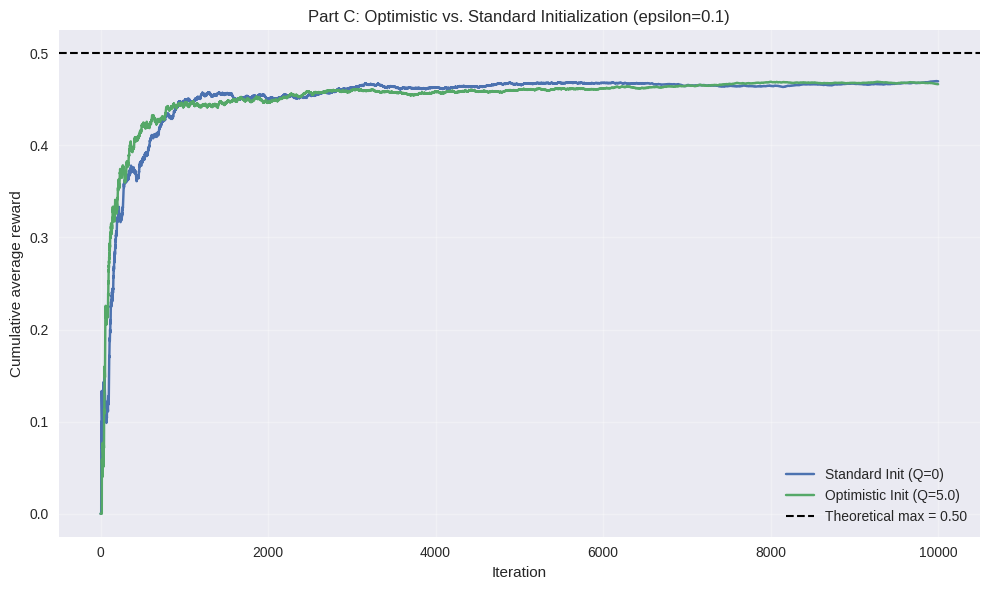

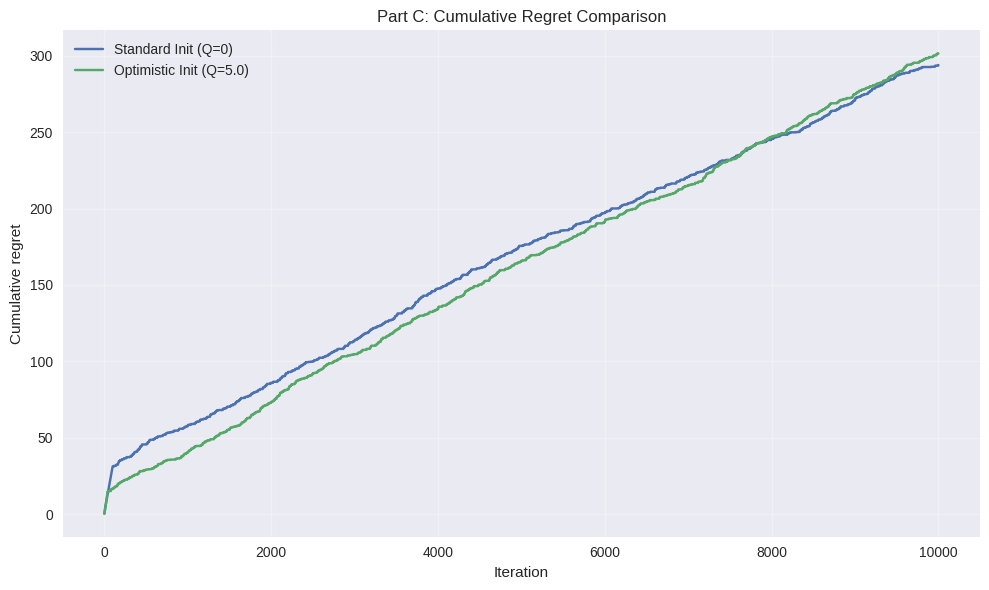

--- Arm Pulls for epsilon = 0.1 ---
Standard Init:       [ 200 9107  268  194  231]
Optimistic Init: [ 236 9127  217  232  188]


In [5]:
OPTIMISTIC_INITIAL_Q = 5.0
epsilon_c = 0.10

# Run with standard (zero) initialization
Q_std, N_std, r_std, _, regrets_std = run_bandit(epsilon_c, N, true_probs, initial_q=0.0, rng=rng)

# Run with optimistic initialization
Q_opt, N_opt, r_opt, _, regrets_opt = run_bandit(epsilon_c, N, true_probs, initial_q=OPTIMISTIC_INITIAL_Q, rng=rng)

# Create plots
plot_cumavg(
    [cumulative_average(r_std), cumulative_average(r_opt)],
    ['Standard Init (Q=0)', 'Optimistic Init (Q={})'.format(OPTIMISTIC_INITIAL_Q)],
    p_opt=float(true_probs.max()),
    title='Part C: Optimistic vs. Standard Initialization (epsilon={})'.format(epsilon_c)
)
plot_regret(
    [np.cumsum(regrets_std), np.cumsum(regrets_opt)],
    ['Standard Init (Q=0)', 'Optimistic Init (Q={})'.format(OPTIMISTIC_INITIAL_Q)],
    title='Part C: Cumulative Regret Comparison'
)

# Print summary
print('--- Arm Pulls for epsilon = {} ---'.format(epsilon_c))
print('Standard Init:       {}'.format(N_std))
print('Optimistic Init: {}'.format(N_opt))